<a href="https://colab.research.google.com/github/parthakk07/Movie-Dataset-Analysis/blob/main/notebook403318dd85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sumitkumar1802_movies_dataset2000_2026_path = kagglehub.dataset_download('sumitkumar1802/movies-dataset2000-2026')
parthakkumar_top_rated_movies_path = kagglehub.dataset_download('parthakkumar/top-rated-movies')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/parthakkumar/top-rated-movies/Top_rated_movies (1).csv
/kaggle/input/datasets/sumitkumar1802/movies-dataset2000-2026/Top_rated_movies (1).csv
/kaggle/input/datasets/sumitkumar1802/movies-dataset2000-2026/movie_data.csv


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/kaggle/input/datasets/parthakkumar/top-rated-movies/Top_rated_movies (1).csv")
df.sample(5)

,id,title,original_language,original_title,overview,release_date,popularity,vote_count,rating
7174,1653208,The Great Grand Superhero,hi,The Great Grand Superhero,NaN,2026-05-29,5.4734,0,0.000
4667,9297,Monster House,en,Monster House,"Monsters under the bed are scary enough, but w...",2006-06-30,6.2944,4328,6.710
8684,578701,Those Who Wish Me Dead,en,Those Who Wish Me Dead,A young boy finds himself pursued by two assas...,2021-05-05,6.2045,1849,6.607
4909,1576198,Madulas,en,Madulas,"At the luxurious Wet & Wild Resort, a group of...",2025-11-14,6.4494,1,4.000
7534,1653208,The Great Grand Superhero,hi,The Great Grand Superhero,NaN,2026-05-29,5.4734,0,0.000


In [ ]:
df.isnull().sum()

id                     0
title                  0
original_language      0
original_title         0
overview             500
release_date           0
popularity             0
vote_count             0
rating                 0
dtype: int64

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipykernel_58/3102881434.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["vote_count"])


<Axes: xlabel='vote_count', ylabel='Density'>

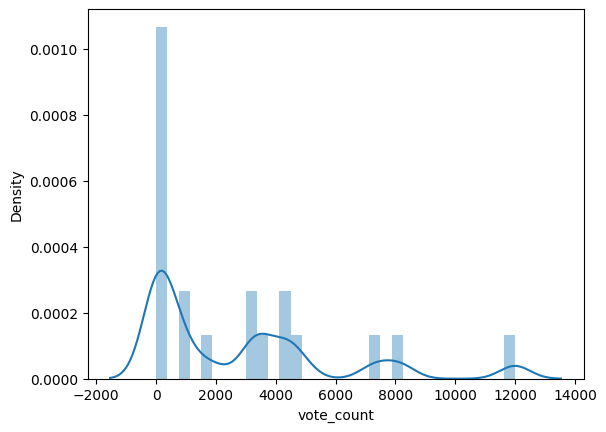

In [ ]:
sns.distplot(df["vote_count"])

/tmp/ipykernel_58/705048343.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["rating"])


<Axes: xlabel='rating', ylabel='Density'>

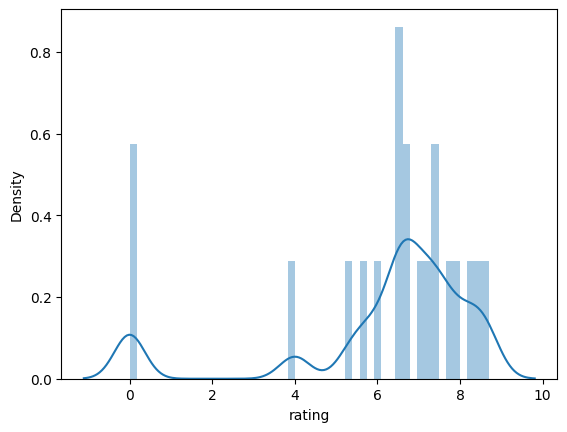

In [ ]:
sns.distplot(df["rating"])

In [ ]:
df["original_language"].unique()

array(['en', 'ja', 'zh', 'tl', 'cn', 'hi'], dtype=object)

<Axes: xlabel='original_language', ylabel='Count'>

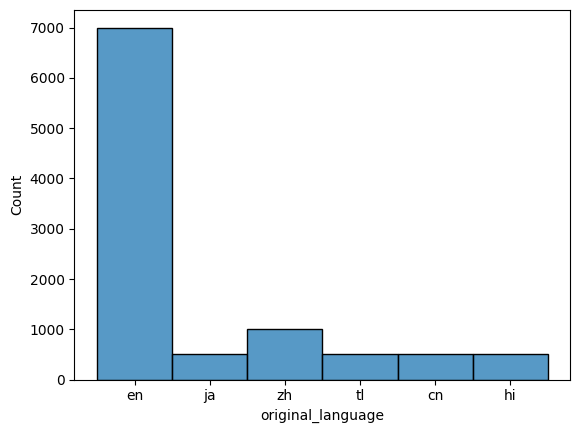

In [ ]:
sns.histplot(x=df["original_language"])

<Axes: >

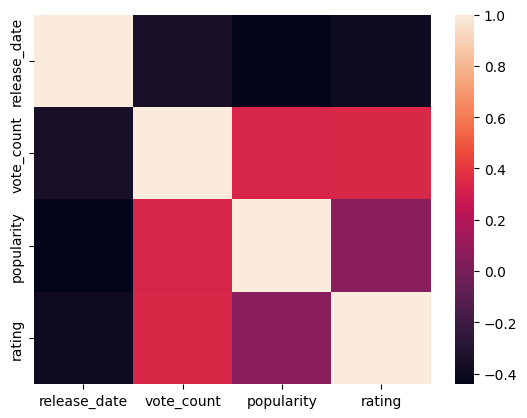

In [ ]:
df["release_date"]=pd.to_datetime(df["release_date"])
col=["release_date","vote_count","popularity","rating"]
sns.heatmap(df[col].corr())

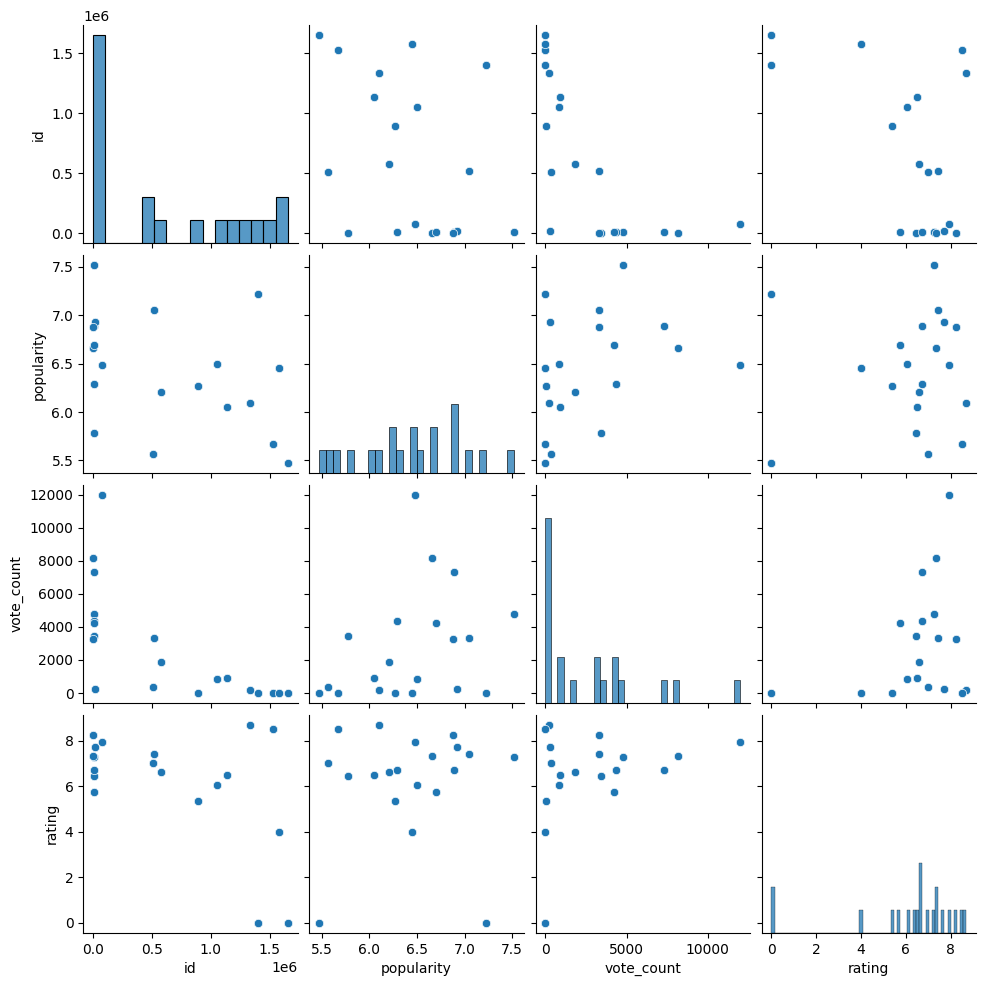

In [ ]:
sns.pairplot(df)

In [ ]:
X=df[col].drop(["release_date","rating"],axis=1)
y=df["rating"]
X

,vote_count,popularity
0,7323,6.8861
1,4801,7.5190
2,3421,5.7786
3,205,6.0979
4,1849,6.2045
...,...,...
9995,0,7.2231
9996,11993,6.4827
9997,3313,7.0485
9998,918,6.0546


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.preprocessing import power_transform
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score , mean_squared_error
from sklearn.compose import ColumnTransformer

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train

,vote_count,popularity
9254,0,5.4734
1561,4801,7.5190
1670,864,6.4993
6087,4328,6.2944
6669,1,6.4494
...,...,...
5734,0,5.4734
5191,4242,6.6964
5390,864,6.4993
860,7323,6.8861


In [ ]:
trf=ColumnTransformer([("sc",StandardScaler(),["vote_count","popularity"]),("pt",PowerTransformer(),["popularity","vote_count"])],remainder="passthrough")

In [ ]:
X_train=trf.fit_transform(X_train)
X_test=trf.transform(X_test)
X_train

array([[-0.85882645, -1.76583129, -1.7673712 , -1.58862418],
       [ 0.61715105,  1.98346598,  1.98137884,  0.87081366],
       [-0.59320584,  0.11449921,  0.11520686, -0.03615383],
       ...,
       [-0.59320584,  0.11449921,  0.11520686, -0.03615383],
       [ 1.3924927 ,  0.82344924,  0.82365001,  1.15073242],
       [-0.59320584,  0.11449921,  0.11520686, -0.03615383]])

In [ ]:
lr=LinearRegression()
dt=DecisionTreeRegressor()
svr=SVR()
rf=RandomForestRegressor()
lr.fit(X_train,Y_train)
dt.fit(X_train,Y_train)
svr.fit(X_train,Y_train)
rf.fit(X_train,Y_train)
y_pred1=lr.predict(X_test)
y_pred2=dt.predict(X_test)
y_pred3=svr.predict(X_test)
y_pred4=rf.predict(X_test)

In [ ]:
print(f"{r2_score(Y_test,y_pred1)} , {mean_squared_error(Y_test,y_pred1)}")

0.41460289768825065 , 3.292514350393895


In [ ]:
print(f"{r2_score(Y_test,y_pred2)} , {mean_squared_error(Y_test,y_pred2)}")

1.0 , 1.1605027440014932e-27


In [ ]:
print(f"{r2_score(Y_test,y_pred3)} , {mean_squared_error(Y_test,y_pred3)}")

0.9871456734935683 , 0.07229802525489105


In [ ]:
print(f"{r2_score(Y_test,y_pred4)} , {mean_squared_error(Y_test,y_pred4)}")

1.0 , 3.1733665406506685e-28


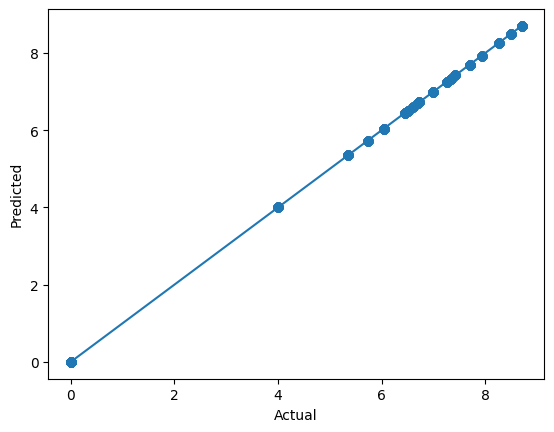

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(Y_test, y_pred2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()])
plt.show()